# Running polarimetric fits with an MCMC

_Weights used:_
* Spatial
* Spectral

LeakageLib provides a simple way to run polarimetric fits with an MCMC. You would use the `fit_mcmc` function instead of `fit`. This is a great way to handle non-Gaussian posteriors.

This example recreates the simulated data point source fit example, with mcmc fitting. First, we repeat the setup described in that example.

In [1]:
import leakagelib

datas = leakagelib.IXPEData.load_all_detectors_with_path("data", "ps")
for data in datas:
    data.iterative_centroid_center()
    data.retain(data.evt_energies > 2)
    data.retain(data.evt_energies < 8)

settings = leakagelib.FitSettings(datas)
settings.apply_circular_roi(280)

settings.add_point_source() # Named "src" by default
settings.fix_flux("src", 1)
settings.set_initial_qu("src", (0.5,0))
settings.set_spectrum("src", lambda e: e**-1.5) # Gamma=1.5, unabsorbed powerlaw

settings.add_background() # Named "bkg" by default
settings.fix_qu("bkg", (0, 0)) # Assume an unpolarized background
settings.set_spectrum("bkg", lambda e: e**-2.5) # Gamma=2.5, unabsorbed powerlaw

fitter = leakagelib.Fitter(settings)

>>> PyXSPEC is not installed, you will no be able to use it.
>>> Reading (in memory) /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/xrt/bcf/vign/ixpe_d1_obssim20240101_vign_v013.fits...
6282 events were cut for being outside the region of interest.
>>> Reading (in memory) /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/gpd/cpf/arf/ixpe_d1_obssim20240101_v013.arf...
>>> Using cached xEffectiveArea object at /opt/homebrew/anaconda3/lib/python3.12/site-packages/ixpeobssim/caldb/ixpe/gpd/cpf/arf/ixpe_d1_obssim20240101_v013.arf...
Data set ps DU 1 had no exposure map loaded. Please load an exposure map if you are fitting to events in the vignetted portion.


Now we perform an MCMC fit simply by using the `fit_mcmc` function instead of `fit`. Note that you can save the mcmc samples to a file if you wish, using the `save_samples` argument.

In [2]:
result = fitter.fit_mcmc(n_iter=1000)

100%|██████████| 1000/1000 [00:59<00:00, 16.68it/s]


Plotting the results shows that they suffer from a burnin problem:

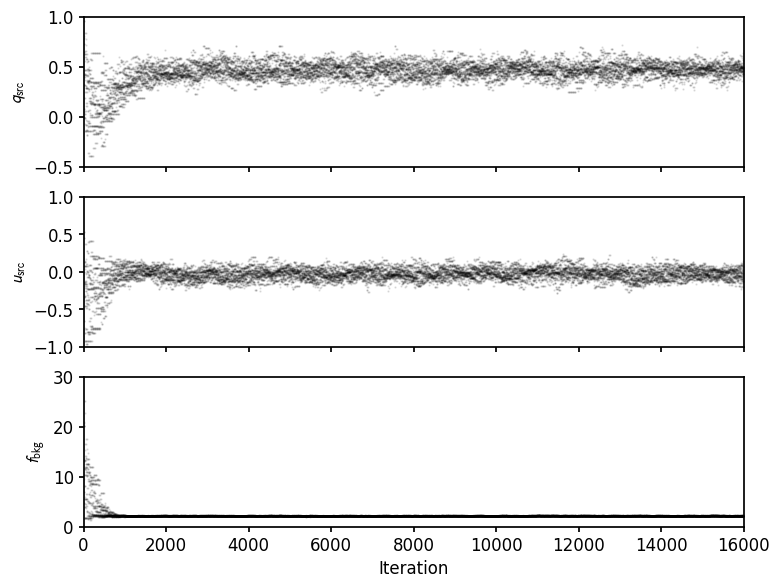

In [3]:
result.display_samples();

We can address this by removing the first few events

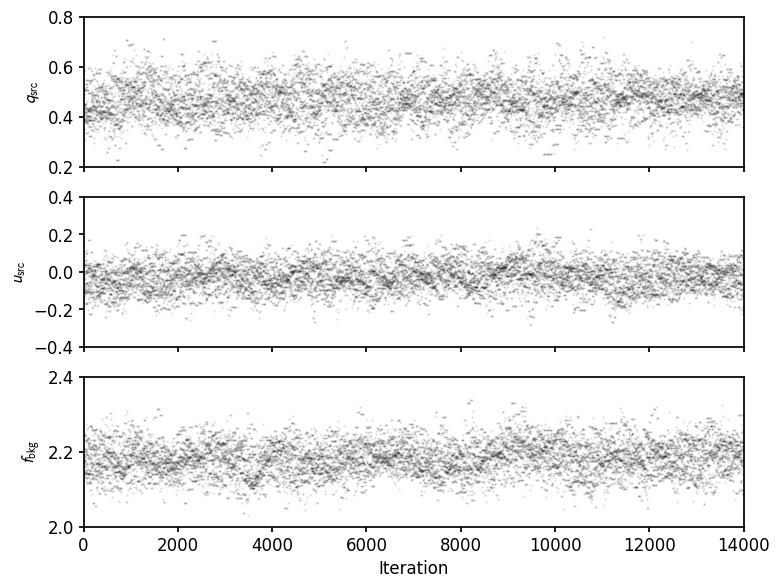

In [4]:
result.burnin(2000)
result.display_samples();

The corner plot shows nice uncertainties as well

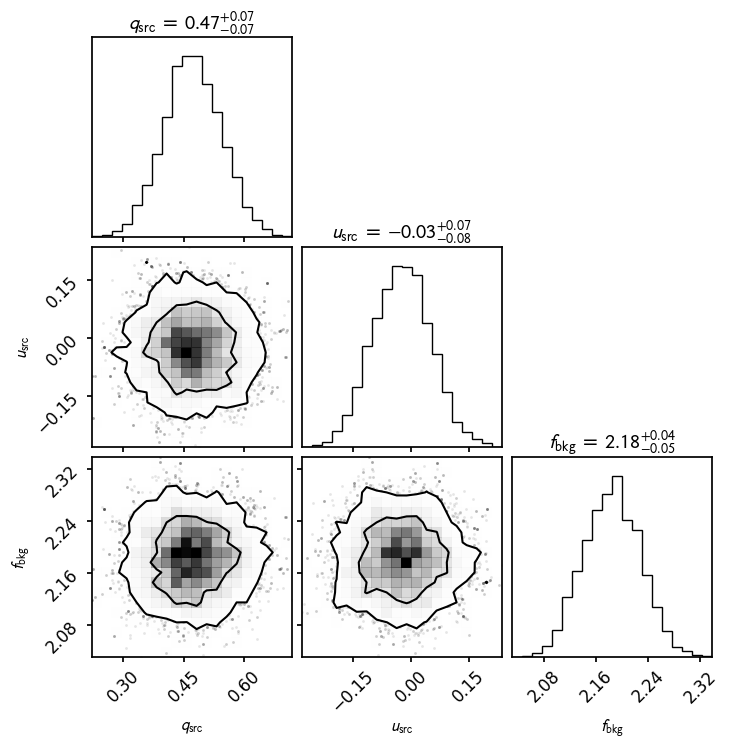

In [5]:
result.display_corner();

This fit result still acts like a normal fit result, and you can still print it to get Gaussian uncertainties (the covariance of the parameters). These are quite similar to the results obtained through the Gaussian-approxmating LeakageLib fit (see the point source example).

You can also access the `result.samples` array to get all the fit samples, and `result.samples[result. sample_mask]` to get all the samples after the burnin was removed.

In [6]:
print(result)

print("\nAll samples: ", result.samples)
print("\nSamples after burnin: ", result.samples[result.sample_mask])

FitResult:
	q (src) = 0.4666 +/- 0.0721
	u (src) = -0.0260 +/- 0.0749
	f (bkg) = 2.1820 +/- 0.0436

Polarization:
	PD (src): 0.4674 +/- 0.0721
	PA (src): -1.5933 deg +/- 4.5935
Likelihood 17886.600143040232, dof 15891
MCMC fit

All samples:  [[ 7.23558699e-01  1.22015827e-03  1.33389783e+01]
 [ 7.83897305e-01 -3.89750924e-01  2.09590413e+01]
 [ 9.52895964e-01  5.36160994e-01  2.01392027e+01]
 ...
 [ 4.92181657e-01 -1.64708106e-02  2.18119864e+00]
 [ 4.91316536e-01 -3.91099556e-02  2.20751338e+00]
 [ 4.59765405e-01 -1.92532946e-02  2.23687075e+00]]

Samples after burnin:  [[ 0.42312855 -0.03353723  2.17694902]
 [ 0.33382468 -0.01372145  2.16199754]
 [ 0.58382084 -0.03081405  2.17405479]
 ...
 [ 0.49218166 -0.01647081  2.18119864]
 [ 0.49131654 -0.03910996  2.20751338]
 [ 0.4597654  -0.01925329  2.23687075]]
